# Anomaly Detection

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.ensemble import IsolationForest

from analytics.db import run_query

In [3]:
fact_profit_loss = run_query("""
SELECT *
FROM fact_profit_loss
""")

fact_balance_sheet = run_query("""
SELECT *
FROM fact_balance_sheet
""")

In [ ]:
fact_profit_loss.head()


,id,company_id,year,equity_capital,reserves,borrowings,other_liabilities,total_liabilities,fixed_assets,cwip,investments,other_asset,total_assets,fiscal_year,sorting_order,debt_to_equity,equity_ratio
0,136,ABB,Dec 2012,21.0,626.0,0.0,260.0,907.0,109.0,1.0,0.0,798.0,907.0,2012,2012,0.0,0.713341
1,137,ABB,Mar 2014,21.0,767.0,0.0,351.0,1139.0,98.0,1.0,0.0,1040.0,1139.0,2014,2014,0.0,0.691835
2,138,ABB,Mar 2015,21.0,916.0,0.0,436.0,1374.0,96.0,4.0,0.0,1274.0,1374.0,2015,2015,0.0,0.681951
3,139,ABB,Mar 2016,21.0,1174.0,0.0,421.0,1616.0,108.0,3.0,0.0,1505.0,1616.0,2016,2016,0.0,0.739480
4,140,ABB,Mar 2017,21.0,1366.0,0.0,679.0,2066.0,110.0,6.0,0.0,1950.0,2066.0,2017,2017,0.0,0.671346


In [5]:
fact_balance_sheet.head()

,id,company_id,year,equity_capital,reserves,borrowings,other_liabilities,total_liabilities,fixed_assets,cwip,investments,other_asset,total_assets,fiscal_year,sorting_order,debt_to_equity,equity_ratio
0,136,ABB,Dec 2012,21.0,626.0,0.0,260.0,907.0,109.0,1.0,0.0,798.0,907.0,2012,2012,0.0,0.713341
1,137,ABB,Mar 2014,21.0,767.0,0.0,351.0,1139.0,98.0,1.0,0.0,1040.0,1139.0,2014,2014,0.0,0.691835
2,138,ABB,Mar 2015,21.0,916.0,0.0,436.0,1374.0,96.0,4.0,0.0,1274.0,1374.0,2015,2015,0.0,0.681951
3,139,ABB,Mar 2016,21.0,1174.0,0.0,421.0,1616.0,108.0,3.0,0.0,1505.0,1616.0,2016,2016,0.0,0.739480
4,140,ABB,Mar 2017,21.0,1366.0,0.0,679.0,2066.0,110.0,6.0,0.0,1950.0,2066.0,2017,2017,0.0,0.671346


In [11]:
latest_borrowings = fact_balance_sheet.sort_values(
    "sorting_order",
    ascending=False
).groupby("company_id").first().reset_index()

latest_borrowings = latest_borrowings[
    [
        "company_id",
        "borrowings"
    ]
]

anomaly_df = fact_profit_loss[
    [
        "company_id",
        "sales",
        "net_profit",
        "operating_profit"
    ]
].copy()

anomaly_df = anomaly_df.merge(
    latest_borrowings,
    on="company_id",
    how="left"
)

In [12]:
anomaly_df.shape

(1276, 5)

In [13]:
anomaly_df.head()

,company_id,sales,net_profit,operating_profit,borrowings
0,ABB,6066.0,1285.0,1547.0,60.0
1,ADANIENSOL,22099.0,589.0,6592.0,39009.0
2,ADANIENT,102311.0,6086.0,13893.0,80427.0
3,ADANIGREEN,10782.0,1928.0,8100.0,67430.0
4,ADANIPORTS,28443.0,9743.0,17165.0,50485.0


In [14]:
numeric_cols = [
    "sales",
    "net_profit",
    "operating_profit",
    "borrowings"
]

z_scores = np.abs(
    zscore(
        anomaly_df[numeric_cols]
    )
)
anomaly_df["zscore_anomaly"] = (
    (z_scores > 3).any(axis=1)
)

zscore_anomalies = anomaly_df[
    anomaly_df["zscore_anomaly"] == True
]

zscore_anomalies.head(20)

,company_id,sales,net_profit,operating_profit,borrowings,zscore_anomaly
21,BPCL,445601.0,13734.0,26554.0,58880.0,True
39,HDFCBANK,329022.0,72168.0,206009.0,3107503.0,True
44,ICICIBANK,180551.0,52416.0,125722.0,1651008.0,True
49,IOC,761485.0,10909.0,32930.0,163401.0,True
58,LICI,896106.0,41468.0,25851.0,10.0,True
69,ONGC,658694.0,42320.0,85870.0,191489.0,True
75,RELIANCE,939838.0,79941.0,164128.0,357525.0,True
77,SBIN,469625.0,74461.0,-59190.0,NaN,True
82,TATAMOTORS,440061.0,33816.0,60497.0,106549.0,True
85,TCS,252082.0,49006.0,67591.0,9046.0,True


In [15]:
zscore_anomalies.shape

(54, 6)

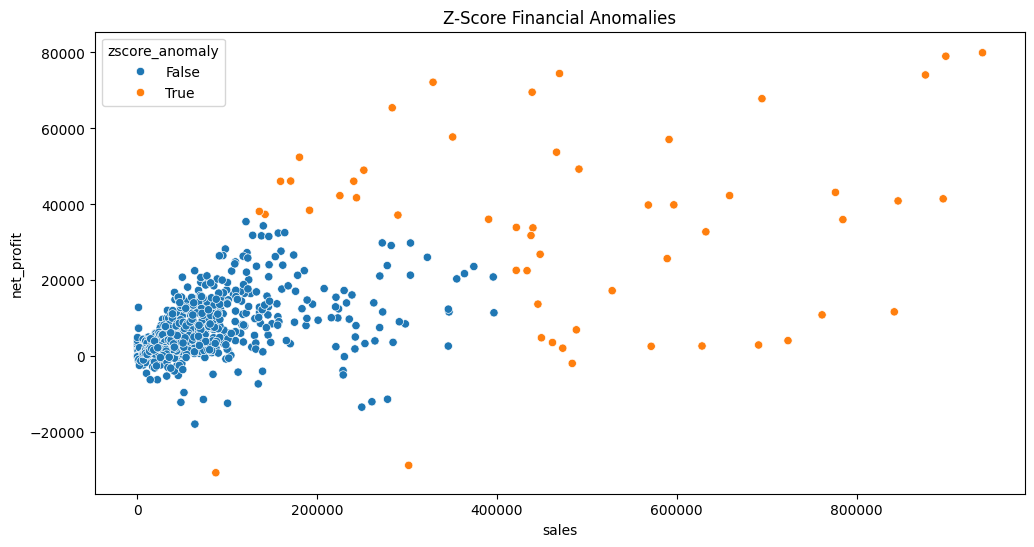

In [16]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=anomaly_df,
    x="sales",
    y="net_profit",
    hue="zscore_anomaly"
)

plt.title("Z-Score Financial Anomalies")

plt.show()

In [17]:
features = anomaly_df[
    [
        "sales",
        "net_profit",
        "operating_profit",
        "borrowings"
    ]
].fillna(0)

In [18]:
iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_model.fit(features)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [19]:
anomaly_df["isolation_forest_flag"] = (
    iso_model.predict(features)
)

In [20]:
anomaly_df["isolation_anomaly"] = (
    anomaly_df["isolation_forest_flag"] == -1
)

In [21]:
isolation_anomalies = anomaly_df[
    anomaly_df["isolation_anomaly"] == True
]

isolation_anomalies.head(20)

,company_id,sales,net_profit,operating_profit,borrowings,zscore_anomaly,isolation_forest_flag,isolation_anomaly
39,HDFCBANK,329022.0,72168.0,206009.0,3107503.0,True,-1,True
42,HINDALCO,224018.0,12488.0,196087.0,60959.0,False,-1,True
44,ICICIBANK,180551.0,52416.0,125722.0,1651008.0,True,-1,True
49,IOC,761485.0,10909.0,32930.0,163401.0,True,-1,True
58,LICI,896106.0,41468.0,25851.0,10.0,True,-1,True
69,ONGC,658694.0,42320.0,85870.0,191489.0,True,-1,True
75,RELIANCE,939838.0,79941.0,164128.0,357525.0,True,-1,True
77,SBIN,469625.0,74461.0,-59190.0,NaN,True,-1,True
82,TATAMOTORS,440061.0,33816.0,60497.0,106549.0,True,-1,True
85,TCS,252082.0,49006.0,67591.0,9046.0,True,-1,True


In [22]:
isolation_anomalies.shape

(64, 8)

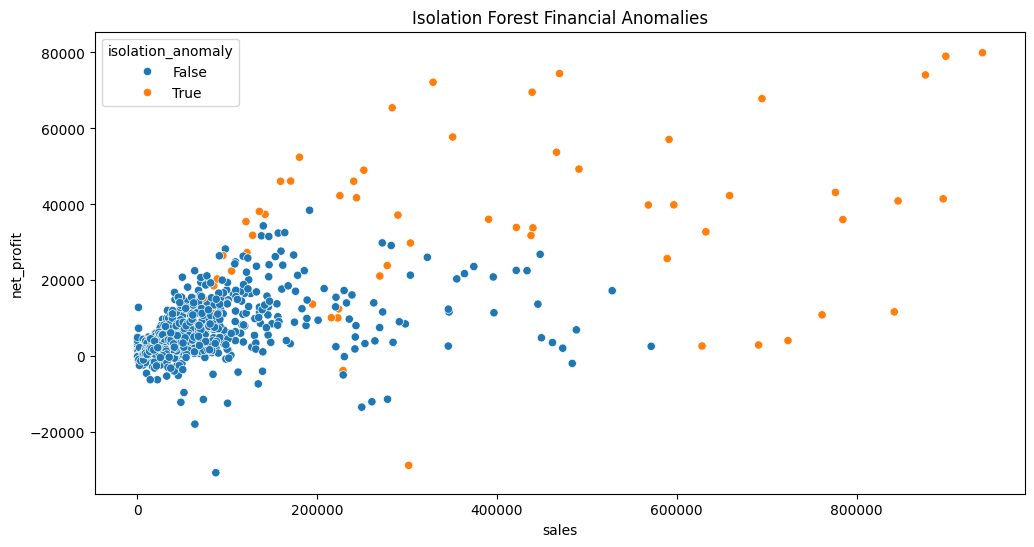

In [23]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=anomaly_df,
    x="sales",
    y="net_profit",
    hue="isolation_anomaly"
)

plt.title("Isolation Forest Financial Anomalies")

plt.show()

In [24]:
anomaly_df.to_csv(
    "../exports/anomaly_detection_results.csv",
    index=False
)